✓ fig1_tipo_biomarcador_pie.png


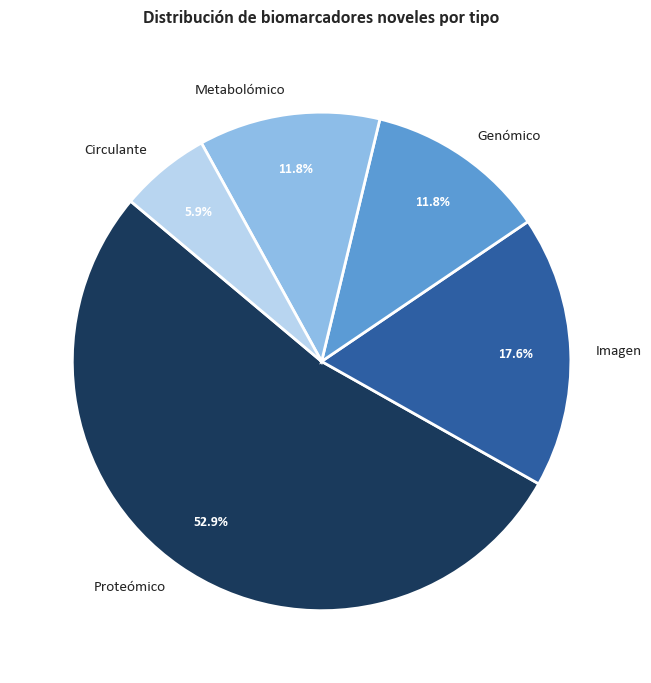

In [28]:
### import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import textwrap
import os

BASE_DIR = r"C:\Users\axdrx\OneDrive\Escritorio\TFM\Extraccion"
FIGS_DIR = os.path.join(BASE_DIR, "figuras")
os.makedirs(FIGS_DIR, exist_ok=True)

biomarks = pd.read_csv(os.path.join(BASE_DIR, "tabla_biomarcadores.csv"), encoding='utf-8-sig')
estudios = pd.read_csv(os.path.join(BASE_DIR, "tabla_estudios.csv"),       encoding='utf-8-sig')

# Estilo
sns.set_theme(style="whitegrid", font="Calibri")
PALETA = ["#1a3a5c", "#2E5FA3", "#5B9BD5", "#8DBDE8", "#B8D5F0", "#D9EAF8"]

def guardar(fig, nombre):
    ruta = os.path.join(FIGS_DIR, f"{nombre}.png")
    fig.savefig(ruta, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✓ {nombre}.png")
    plt.show()

# Figura 1: Distribución por tipo de biomarcador

conteo_tipo = biomarks["biomarker_type"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    conteo_tipo.values,
    labels=conteo_tipo.index,
    autopct='%1.1f%%',
    colors=PALETA[:len(conteo_tipo)],
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(linewidth=2, edgecolor='white'),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title("Distribución de biomarcadores noveles por tipo",
             fontsize=13, fontweight='bold', pad=20)
fig.tight_layout()
guardar(fig, "fig1_tipo_biomarcador_pie")

C:\Users\axdrx\AppData\Local\Temp\ipykernel_5980\1169797644.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conteo_muestra, x="Muestra", y="n",


✓ fig2_tipo_muestra_bar.png


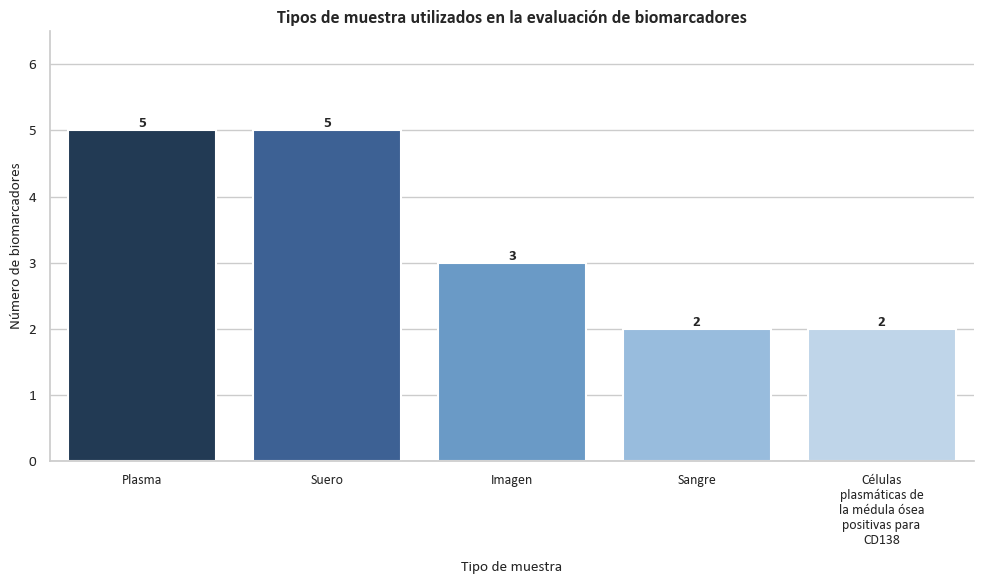

In [29]:
# Figura 2: Distribución por tipo de muestra

conteo_muestra = biomarks["sample_type"].value_counts().reset_index()
conteo_muestra.columns = ["Muestra", "n"]
conteo_muestra["Muestra"] = conteo_muestra["Muestra"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=14))
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=conteo_muestra, x="Muestra", y="n",
            palette=PALETA[:len(conteo_muestra)], ax=ax,
            edgecolor='white', linewidth=1.5)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel("Tipo de muestra", fontsize=11, labelpad=10)
ax.set_ylabel("Número de biomarcadores", fontsize=11)
ax.set_title("Tipos de muestra utilizados en la evaluación de biomarcadores",
             fontsize=13, fontweight='bold')
ax.set_ylim(0, conteo_muestra["n"].max() + 1.5)
ax.tick_params(axis='x', labelsize=10)
sns.despine()
fig.tight_layout()
guardar(fig, "fig2_tipo_muestra_bar")

C:\Users\axdrx\AppData\Local\Temp\ipykernel_5980\364665977.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conteo_purpose, y="Propósito", x="n",


✓ fig3_proposito_clinico_barh.png


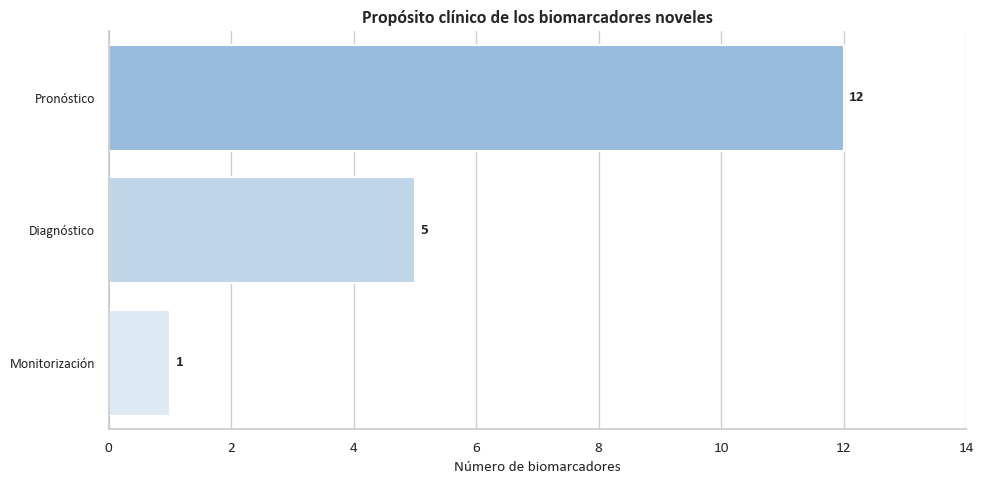

In [30]:
# Figura 3: Distribución por propósito clínico
# normalizar: separar entradas múltiples y limpiar
def normalizar_purpose(texto):
    if pd.isna(texto):
        return []
    import re
    resultado = []
    partes = re.split(r'\s+y\s+|,|/', str(texto))
    for p in partes:
        p = p.strip()
        p_low = p.lower()
        if "diagn" in p_low:
            resultado.append("Diagnóstico")
        elif "pron" in p_low:
            resultado.append("Pronóstico")
        elif "monitor" in p_low:
            resultado.append("Monitorización")
    return resultado

purposes = biomarks["clinical_purpose"].apply(normalizar_purpose).explode()
conteo_purpose = purposes.value_counts().reset_index()
conteo_purpose.columns = ["Propósito", "n"]
conteo_purpose["Propósito"] = conteo_purpose["Propósito"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=25))
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=conteo_purpose, y="Propósito", x="n",
            palette=PALETA[3:3+len(conteo_purpose)], ax=ax,
            edgecolor='white', linewidth=1.5, orient='h')

for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11,
                fontweight='bold', xytext=(4, 0),
                textcoords='offset points')

ax.set_xlabel("Número de biomarcadores", fontsize=11)
ax.set_ylabel("")
ax.set_title("Propósito clínico de los biomarcadores noveles",
             fontsize=13, fontweight='bold')
ax.set_xlim(0, conteo_purpose["n"].max() + 2)
ax.tick_params(axis='y', labelsize=10)
sns.despine()
fig.tight_layout()
guardar(fig, "fig3_proposito_clinico_barh")

✓ fig4_tecnicas_bar.png


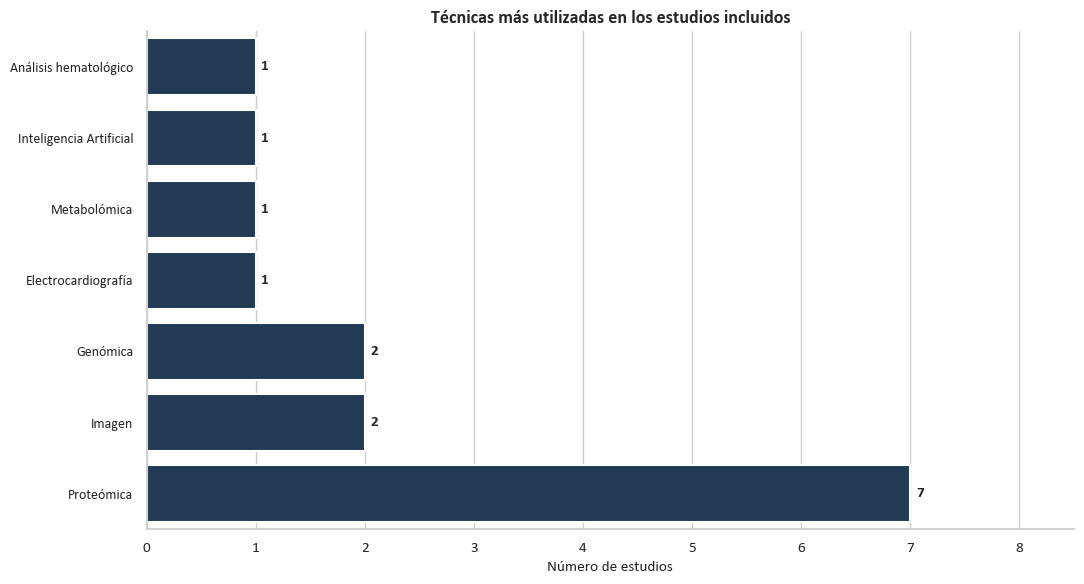


✓ Figuras guardadas en: C:\Users\axdrx\OneDrive\Escritorio\TFM\Extraccion\figuras


In [31]:
# Figura 5: Distribución por técnicas

def normalizar_tecnica(texto):
    if pd.isna(texto):
        return []
    import re
    resultado = []
    partes = re.split(r';', str(texto))
    for p in partes:
        p = p.strip()
        if not p:
            continue
        p_low = p.lower()
        if ("prot" in p_low) and ("inteligencia" in p_low or "artificial" in p_low or " ia" in p_low):
            resultado.append("Proteómica")
            resultado.append("Inteligencia Artificial")
        elif "prot" in p_low:
            resultado.append("Proteómica")
        elif "genom" in p_low or "ngs" in p_low or "array" in p_low or "sanger" in p_low:
            resultado.append("Genómica")
        elif "imagen" in p_low or "resonancia" in p_low or "cmr" in p_low:
            resultado.append("Imagen")
        elif "metabol" in p_low:
            resultado.append("Metabolómica")
        elif "hematol" in p_low or "lisis" in p_low:
            resultado.append("Análisis hematológico")
        elif "electrocardiograf" in p_low:
            resultado.append("Electrocardiografía")
        elif "inteligencia" in p_low or "artificial" in p_low:
            resultado.append("Inteligencia Artificial")
    return resultado
    
tecnicas_norm = estudios["techniques"].apply(normalizar_tecnica).explode()
tecnicas_norm = tecnicas_norm[tecnicas_norm.notna() & (tecnicas_norm != "")]
conteo_tec = tecnicas_norm.value_counts().reset_index()
conteo_tec.columns = ["Técnica", "n"]
conteo_tec = conteo_tec.sort_values("n")


fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=conteo_tec, y="Técnica", x="n",
            color=PALETA[0], ax=ax,
            edgecolor='white', linewidth=1.5, orient='h')

for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11,
                fontweight='bold', xytext=(4, 0),
                textcoords='offset points')

ax.set_xlabel("Número de estudios", fontsize=11)
ax.set_ylabel("")
ax.set_title("Técnicas más utilizadas en los estudios incluidos",
             fontsize=13, fontweight='bold')
ax.set_xlim(0, conteo_tec["n"].max() + 1.5)
ax.tick_params(axis='y', labelsize=10)
sns.despine()
fig.tight_layout()
guardar(fig, "fig4_tecnicas_bar")

print(f"\n✓ Figuras guardadas en: {FIGS_DIR}")

In [32]:
# extraer subtécnicas (lo que va después de los dos puntos)
subtecnicas = estudios["techniques"].dropna().str.split(";").explode().str.strip()
subtecnicas_limpias = subtecnicas[subtecnicas.str.contains(":", na=False)]
print(subtecnicas_limpias.tolist())

['Proteómica: Inmunoensayo', 'Proteómica: Inmunoensayo', 'Genómica: NGS (secuenciación completa del exoma y secuenciación dirigida de genes) y secuenciación Sanger', 'Proteómica: aglutinación en látex y turbidimetría', 'Proteómica: espectrofotometría', 'Imagen: resonancia magnética cardíaca (CMR)', 'Proteómica: Inmunoensayo', 'Genómica: Array-CGH e iFISH', 'Imagen: resonancia magnética cardíaca (CMR)', 'Metabolómica: LC-MS', 'Proteómica: Inmunoensayo (ELISA), espectrofotometría']


In [34]:
!pip install plotly
!pip install kaleido

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 9.9/9.9 MB 63.2 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------

In [40]:
print(estudios["techniques"].tolist())

['Proteómica: Inmunoensayo', 'Análisis hematológico', 'Electrocardiografía', 'Proteómica: Inmunoensayo ', 'Genómica: NGS (secuenciación completa del exoma y secuenciación dirigida de genes) y secuenciación Sanger', 'Proteómica: aglutinación en látex y turbidimetría', 'Proteómica: espectrofotometría', 'Imagen: resonancia magnética cardíaca (CMR)', 'Proteómica: Inmunoensayo ', 'Genómica: Array-CGH e iFISH', 'Imagen: resonancia magnética cardíaca (CMR)', 'Metabolómica: LC-MS', 'Proteómica, Inteligencia Artificial (IA)', 'Proteómica: Inmunoensayo (ELISA), espectrofotometría']


In [58]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import os
import re

# Figura 5: Distribución por técnicas utilizadas más detallado

BASE_DIR = r"C:\Users\axdrx\OneDrive\Escritorio\TFM\Extraccion"
FIGS_DIR = os.path.join(BASE_DIR, "figuras")
os.makedirs(FIGS_DIR, exist_ok=True)

estudios = pd.read_csv(
    os.path.join(BASE_DIR, "tabla_estudios.csv"),
    encoding="utf-8-sig"
)

# Categorías

def normalizar_categoria(texto):
    texto = str(texto).lower()
    if "prote" in texto:
        return "Proteómica"
    if "genom" in texto:
        return "Genómica"
    if "imagen" in texto:
        return "Imagen"
    if "metabol" in texto:
        return "Metabolómica"
    if "hematol" in texto:
        return "Análisis hematológico"
    if "electrocardiograf" in texto:
        return "Electrocardiografía"
    if ("inteligencia" in texto
        or "(ia)" in texto
        or texto.strip() == "ia"):
        return "Inteligencia Artificial"
    return None


# Extracción técnicas

filas = []

for tecnica in estudios["techniques"].dropna():
    tecnica = str(tecnica).strip()
    if ":" not in tecnica:
        partes = [p.strip() for p in tecnica.split(",")]
        for p in partes:
            categoria = normalizar_categoria(p)
            if not categoria:
                continue
            if categoria in [
                "Análisis hematológico",
                "Electrocardiografía",
                "Inteligencia Artificial"
            ]:
                filas.append(
                    {"categoria": categoria,
                     "subtecnica": categoria}
                )
        continue

    categoria_raw, descripcion = tecnica.split(":", 1)
    categoria = normalizar_categoria(categoria_raw)
    descripcion_low = descripcion.lower()

   

    if categoria == "Proteómica":
        if ("inmunoensayo" in descripcion_low
            or "elisa" in descripcion_low):
            filas.append(
                {"categoria": categoria,
                 "subtecnica": "Inmunoensayo"}
            )
        if ("aglutin" in descripcion_low
            or "turbidimetr" in descripcion_low):
            filas.append(
                {"categoria": categoria,
                 "subtecnica": "Aglutinación / Turbidimetría"
                }
            )
        if "espectrofotometr" in descripcion_low:
            filas.append(
                {"categoria": categoria,
                 "subtecnica": "Espectrofotometría"}
            )

    elif categoria == "Genómica":
        if ("ngs" in descripcion_low 
            or "exoma" in descripcion_low):
            filas.append(
                {"categoria": categoria,
                 "subtecnica": "NGS"}
            )
        if "sanger" in descripcion_low:
            filas.append(
                {"categoria": categoria,
                 "subtecnica": "Secuenciación Sanger"}
            )
        if ("array" in descripcion_low
            or "fish" in descripcion_low):
            filas.append(
                {"categoria": categoria,
                 "subtecnica": "Array-CGH / iFISH"
                }
            )

    elif categoria == "Imagen":
        filas.append(
            {"categoria": categoria,
             "subtecnica": "RMN cardíaca"}
        )

    elif categoria == "Metabolómica":
        filas.append(
            {"categoria": categoria,
             "subtecnica": "LC-MS"}
        )

    elif categoria in [
        "Electrocardiografía",
        "Análisis hematológico",
        "Inteligencia Artificial"
    ]:
        filas.append(
            {"categoria": categoria,
             "subtecnica": categoria}
        )

# Dataframe
df_sun = pd.DataFrame(filas)
conteo = (
    df_sun
    .groupby(["categoria", "subtecnica"])
    .size()
    .reset_index(name="n")
)
print(conteo)

# Gráfico sunburst
import plotly.io as pio
pio.renderers.default = "iframe_connected"

PALETA_SUN = ["#0A2540", "#103B66", "#1B5A8A", "#2A77A6", "#3F95C5", "#63B3DE", "#93D2F3", "#CFEAFB"]

fig = px.sunburst(
    conteo,
    path=["categoria", "subtecnica"],
    values="n",
    color="categoria",
    color_discrete_sequence=PALETA_SUN,
    title="Técnicas utilizadas en los estudios incluidos")

fig.update_traces(
    insidetextorientation="radial",
    textfont_size=12,
    marker=dict(
        line=dict(color="#0A2540", width=2)))

fig.update_layout(
    title=dict(
        x=0.5,
        font=dict(family="Calibri", size=15)),
    font=dict(family="Calibri", size=11),
    width=700,
    height=700,
    margin=dict(t=60, l=0, r=0, b=0))

fig.update_traces(insidetextorientation="auto")
fig.show()

# Exportación

ruta = os.path.join(FIGS_DIR, "fig5_sunburst.png")

pio.write_image(fig, ruta, width=700, height=700, scale=3)

print(f"✓ Guardado en: {ruta}")

                 categoria                    subtecnica  n
0    Análisis hematológico         Análisis hematológico  1
1      Electrocardiografía           Electrocardiografía  1
2                   Imagen                  RMN cardíaca  2
3  Inteligencia Artificial       Inteligencia Artificial  1
4             Metabolómica                         LC-MS  1
5               Proteómica  Aglutinación / Turbidimetría  1
6               Proteómica            Espectrofotometría  2
7               Proteómica                  Inmunoensayo  4


✓ Guardado en: C:\Users\axdrx\OneDrive\Escritorio\TFM\Extraccion\figuras\fig5_sunburst.png
